<a href="https://colab.research.google.com/github/RyanO14/ENGPHYS-2NM4/blob/main/Assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

Due end of day Sunday Sept 20th.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu, solve, solve_triangular
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.sparse import coo_matrix

try:
    import executable_engineering as exe
except ImportError:
    %pip install -q executable_engineering
    import executable_engineering as exe

## Question 1:
{method, implementation, answer}

Examine the value of sparse matricies by comparing the approximate computational efficiencies of sparse and dense solvers (on the same system). Use the %timeit function to approximate the complexity.

HINT: Refer to the lecture notes on how to generate, store, and apply sparse solvers.  

In [ ]:
#Dense
A_dense = np.array([
    [ 2, -1,  0],
    [-1,  2, -1],
    [ 0, -1,  2]
], dtype=float)

#Sparse
A_sparse = diags(
    diagonals=[
        -np.ones(2),
         2*np.ones(3),
        -np.ones(2)
    ],
    offsets=[-1, 0, 1],
    format="csc"
)

#Solver

#Arbitrary RHS
b = np.array([1,2,3], dtype=float)

#Sparse solve
x_sparse = spsolve(A_sparse, b)

print("Solution using sparse solver:")
print("x =")
print(x_sparse.reshape(-1, 1))

#Sparse check.
print("\nCheck that Ax = b:")
print("A @ x =")
print((A_sparse @ x_sparse).reshape(-1, 1))

print("\nb =")
print(b.reshape(-1, 1))

#Dense solve
x_dense = np.linalg.solve(A_dense, b)
print("Solution using dense solver:")
print("x =")
print(x_dense.reshape(-1, 1))


#Ensure spare and dense are the same matrix
#print(A_dense)
#print(A_sparse.toarray())

Solution using sparse solver:
x =
[[2.5]
 [4. ]
 [3.5]]

Check that Ax = b:
A @ x =
[[1.]
 [2.]
 [3.]]

b =
[[1.]
 [2.]
 [3.]]
Solution using dense solver:
x =
[[2.5]
 [4. ]
 [3.5]]


In [ ]:
%timeit spsolve(A_sparse, b)

44.5 µs ± 2.35 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
%timeit np.linalg.solve(A_dense, b)

8.22 µs ± 343 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [ ]:
n = 1000

# Sparse tridiagonal matrix
A_sparse_large = diags(
    diagonals=[
        -np.ones(n - 1),
         2*np.ones(n),
        -np.ones(n - 1)
    ],
    offsets=[-1, 0, 1],
    format="csc"
)

# Dense representation of the identical matrix
A_dense_large = A_sparse_large.toarray()

# Right-hand-side vector with n entries
b_large = np.random.rand(n)

print("Sparse matrix shape:", A_sparse_large.shape)
print("Nonzero entries in sparse matrix:", A_sparse_large.nnz)
print("Entries stored by dense matrix:", n**2)

Sparse matrix shape: (1000, 1000)
Nonzero entries in sparse matrix: 2998
Entries stored by dense matrix: 1000000


In [ ]:
%timeit spsolve(A_sparse_large, b_large)

396 µs ± 11.6 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
%timeit np.linalg.solve(A_dense_large, b_large)

125 ms ± 65.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


The sparse solver is slower on a 3x3 matrix becuase it has extra setup requirements. This extra work does not result in a time save until matricies are larger.

## Question 2

Consider the truss:

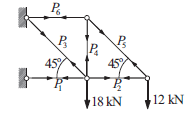


### 2a) Write the linear system for the tensions $P_i$ as equations and in matrix form
{answer}

In [ ]:
#Sine and cosine of 45deg
s = 1/(2 ** 0.5)

#Sparse matrix data
data = [-1, 1, -s, s, 1, -1, -s, s, s, -1, -1, -s]

#Locate data
rows = [0,0,0,1,1,2,2,3,4,4,5,5]
cols = [0,1,2,2,3,1,4,4,4,5,3,4]

#Build matrix
A_sparse = coo_matrix((data, (rows, cols)), shape=(6, 6)).tocsc()

#Verify
print(A_sparse.toarray())

#RHS
b = np.array([0, 18, 0, 12, 0, 0], dtype=float)

#Solve
P = spsolve(A_sparse, b)

print("\nMember forces [P1, P2, P3, P4, P5, P6](^T) in kN")
print(P.reshape(-1, 1))




[[-1.          1.         -0.70710678  0.          0.          0.        ]
 [ 0.          0.          0.70710678  1.          0.          0.        ]
 [ 0.         -1.          0.          0.         -0.70710678  0.        ]
 [ 0.          0.          0.          0.          0.70710678  0.        ]
 [ 0.          0.          0.          0.          0.70710678 -1.        ]
 [ 0.          0.          0.         -1.         -0.70710678  0.        ]]

Member forces [P1, P2, P3, P4, P5, P6](^T) in kN
[[-42.        ]
 [-12.        ]
 [ 42.42640687]
 [-12.        ]
 [ 16.97056275]
 [ 12.        ]]


Negative members are in compression, positive members are in tension

### 2b) Solve for $P_i$ using LU decomposition and substitution.
{method, answer}

In [30]:
A = A_sparse.toarray()

#LU decomposition (w pivoting)
P_perm, L, U = lu(A)

print(f"L = {L}")
print(f"\nU = {U}")


L = [[ 1.  0.  0.  0.  0.  0.]
 [-0.  1.  0.  0.  0.  0.]
 [-0. -0.  1.  0.  0.  0.]
 [-0. -0.  0.  1.  0.  0.]
 [-0. -0.  0. -0.  1.  0.]
 [-0. -0.  0. -0.  1.  1.]]

U = [[-1.          1.         -0.70710678  0.          0.          0.        ]
 [ 0.         -1.          0.          0.         -0.70710678  0.        ]
 [ 0.          0.          0.70710678  1.          0.          0.        ]
 [ 0.          0.          0.         -1.         -0.70710678  0.        ]
 [ 0.          0.          0.          0.          0.70710678 -1.        ]
 [ 0.          0.          0.          0.          0.          1.        ]]


In [34]:
b_permuted = P_perm.T @ b

y = solve_triangular(
    L,
    b_permuted,
    lower=True,
    unit_diagonal=True
)

forces = solve_triangular(
    U,
    y,
    lower=False
)

print("\nMember forces [P1, P2, P3, P4, P5, P6](^T) in kN")
print(forces.reshape(-1, 1))


Member forces [P1, P2, P3, P4, P5, P6](^T) in kN
[[-42.        ]
 [-12.        ]
 [ 42.42640687]
 [-12.        ]
 [ 16.97056275]
 [ 12.        ]]


### 2c)  Double the loads (18 kN and 12 kN) and solve for $P_i$ again *without refactoring*.
{answer}

In [ ]:
b_dubs = 2 * b

b_dubs_perm = P_perm.T @ b_dubs

y_dubs = solve_triangular(
    L,
    b_dubs_perm,
    lower=True,
    unit_diagonal=True
)

forces_dubs = solve_triangular(
    U,
    y_dubs,
    lower=False
)

print("\nMember forces (doubled load) [P1, P2, P3, P4, P5, P6](^T) in kN")
print(forces_dubs.reshape(-1, 1))

## Question 3

Consider the matrix:

$$ A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

## 3a) Calculate the condition number of A
{answer}

## 3b) Let's use a preconditioner matrix $P$ to improve the condition number of the product $P^{-1} A$. Give 2 examples of $P$ that improve the condition number.

Can you identify the 'perfect' preconditioner? (Consider the easiest matrix to solve!)
{answer, answer}